# Food delivery delay prediction 

The goal of this project is to predict whether a food delivery will be delayed using machine learning techniques.

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load the dataset 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from sklearn.preprocessing import StandardScaler


df= pd.read_csv("food_delivery_analytics_cleaned.csv")
df.head(5)

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


In [3]:
df.shape

(15000, 30)

In [4]:
df.dtypes

order_id                              object
city_tier                              int64
customer_age                           int64
customer_loyalty_score               float64
order_hour                             int64
order_day_of_week                      int64
order_month                            int64
delivery_distance_km                 float64
preparation_time_minutes               int64
delivery_time_minutes                  int64
estimated_delivery_time                int64
traffic_level_score                  float64
weather_severity_score               float64
restaurant_rating                    float64
delivery_partner_rating              float64
customer_rating                      float64
order_value                          float64
delivery_fee                         float64
discount_amount                      float64
tip_amount                           float64
final_amount_paid                    float64
number_of_items                        int64
cancellati

In [5]:
# check for missing values
df.isnull().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [6]:
# check duplicated rows
df.duplicated().sum()

np.int64(0)

In [7]:
# Display summary statistics for all numeric columns
df.describe(include="number")

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [8]:
# How many unique city tiers are there?
df["city_tier"].value_counts()

city_tier
3    7520
2    3757
1    3723
Name: count, dtype: int64

In [9]:
# What percentage of orders were cancelled, delayed, or refunded?

print("cancelled: ",df["cancellation_flag"].mean()*100,"%")
print("delayed:",df["delayed_delivery_flag"].mean()*100,"%")
print("Refunded:",df["delayed_delivery_flag"].mean()*100,"%")

cancelled:  13.353333333333333 %
delayed: 9.466666666666667 %
Refunded: 9.466666666666667 %


In [10]:
df.columns

Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')

#  Customer Analysis

In [11]:
# What is the average customer age per city tier?
df.groupby("city_tier")["customer_age"].mean()

city_tier
1    46.734085
2    46.913495
3    46.316489
Name: customer_age, dtype: float64

In [12]:
# Find the average customer_loyalty_score for premium vs non-premium customers

df.groupby("premium_customer_flag")["customer_loyalty_score"].mean()

premium_customer_flag
False    50.095722
True     49.818307
Name: customer_loyalty_score, dtype: float64

true= premium, False = non-premium, so groupby automatically separates them.

In [13]:
# Which age group orders the most? (bin ages into 18-25, 26-35, 36-50, 50+) do it again
df['age_group'] = pd.cut(df['customer_age'], bins=[18,25,35,50,100], labels=['18-25','26-35','36-50','50+'])
df['age_group'].value_counts()

age_group
50+      6434
36-50    3915
26-35    2589
18-25    1811
Name: count, dtype: int64

In [14]:
# Do premium customers give higher ratings than non-premium?
# You are comparing groups (premium vs non-premium) and need an overall rating measure → groupby() + mean().

df.groupby("premium_customer_flag")["customer_rating"].mean()

premium_customer_flag
False    3.990235
True     4.002034
Name: customer_rating, dtype: float64

In [15]:
# What is the average order value for promo code users vs non-users?
df.groupby("promo_code_used")["order_value"].mean()

promo_code_used
False    114.021816
True     113.862172
Name: order_value, dtype: float64

In [16]:
df.dtypes

order_id                               object
city_tier                               int64
customer_age                            int64
customer_loyalty_score                float64
order_hour                              int64
order_day_of_week                       int64
order_month                             int64
delivery_distance_km                  float64
preparation_time_minutes                int64
delivery_time_minutes                   int64
estimated_delivery_time                 int64
traffic_level_score                   float64
weather_severity_score                float64
restaurant_rating                     float64
delivery_partner_rating               float64
customer_rating                       float64
order_value                           float64
delivery_fee                          float64
discount_amount                       float64
tip_amount                            float64
final_amount_paid                     float64
number_of_items                   

# Delivery Analysis

In [17]:
# What is the average delivery time per city tier?

df.groupby("city_tier")["delivery_time_minutes"].mean()

city_tier
1    94.173247
2    93.718659
3    94.332580
Name: delivery_time_minutes, dtype: float64

In [19]:
# Find orders where actual delivery time exceeded estimated delivery time do it again

df[df["delivery_time_minutes"]>df["estimated_delivery_time"]]

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score,age_group
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,4,False,False,True,False,False,True,9,71.1,18-25
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,12,False,False,False,False,False,False,10,34.4,50+
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,2,True,False,False,False,False,False,6,25.1,50+
8,70d9ed9f-fe98-4144-b00d-7ee169bf9d40,3,20,45.128010,21,1,10,9.291364,13,83,...,6,True,True,False,False,False,False,1,39.3,18-25
10,9884ece6-b0ed-46fd-b09d-bc88f2fa6696,3,65,10.273938,3,3,7,6.784406,39,65,...,11,False,False,False,True,False,False,14,91.4,50+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984,88c48a6f-c628-486f-b97c-ddf14796d9db,1,57,76.195024,22,2,12,3.361031,57,75,...,12,False,False,False,False,True,False,3,60.3,50+
14985,b9cc64c0-9642-4480-be69-728de3efd89f,3,34,60.405796,6,2,8,21.401494,46,122,...,8,False,False,False,True,False,False,1,27.1,26-35
14989,a4dc7271-08ee-4c66-9deb-48f3815d3ba2,3,42,67.360967,17,1,7,10.406598,32,85,...,3,True,False,False,True,False,False,11,54.6,36-50
14994,8f789400-14ea-4fb4-88b1-a472808b4a21,2,61,18.983388,18,4,10,20.285461,38,105,...,8,False,False,False,False,False,False,12,59.4,50+


In [18]:
# What percentage of orders were delayed?

print("delayed :",df["delayed_delivery_flag"].mean()*100,"%")

delayed : 9.466666666666667 %


In [19]:
# How does traffic level affect delivery time?

df.groupby("traffic_level_score")["delivery_time_minutes"].mean()

traffic_level_score
1.0      85.961104
1.1      85.977778
1.2      85.360544
1.3      87.755725
1.4      87.796703
           ...    
9.6     102.308725
9.7     105.107383
9.8     104.809859
9.9     102.270440
10.0    101.552941
Name: delivery_time_minutes, Length: 91, dtype: float64

In [20]:
# Does weather severity impact delivery time?
df.groupby("weather_severity_score")["delivery_time_minutes"].mean()

weather_severity_score
0.0      87.757576
0.1      85.773973
0.2      87.542857
0.3      80.390977
0.4      83.756410
           ...    
9.6     102.560510
9.7     101.628049
9.8      97.926471
9.9     102.605096
10.0    100.171429
Name: delivery_time_minutes, Length: 101, dtype: float64

In [21]:
# Which delivery partners (by experience years) are most efficient?

df.groupby("delivery_partner_experience_years")["delivery_time_minutes"].mean()

delivery_partner_experience_years
1     94.035897
2     93.873494
3     93.454936
4     94.036623
5     95.251721
6     95.792233
7     91.802243
8     93.694359
9     94.120414
10    92.880884
11    96.020690
12    94.532353
13    93.966387
14    94.173018
15    94.280267
Name: delivery_time_minutes, dtype: float64

# order revenue analysis

In [22]:
# What is the busiest hour of the day for orders? do it again

df.groupby("order_hour")["order_id"].count().idxmax()

np.int64(0)

In [23]:
# Which day of the week has the highest order value?
df.groupby("order_day_of_week")["order_value"].sum().idxmax()

np.int64(1)

In [24]:
# Find total revenue per month

df.groupby("order_month")["final_amount_paid"].sum()

order_month
1     153459.652913
2     149591.517993
3     150698.047531
4     144571.295443
5     148574.705215
6     147014.085632
7     149165.858865
8     155567.374148
9     148794.077840
10    146617.995602
11    143693.171094
12    148507.491605
Name: final_amount_paid, dtype: float64

In [25]:
# What is the average discount given per city tier?

df.groupby("city_tier")["discount_amount"].mean()

city_tier
1    14.959925
2    15.148907
3    14.810967
Name: discount_amount, dtype: float64

In [26]:
# How much tip is given on festival/weekend vs normal days?

df.groupby("festival_or_weekend_flag")["tip_amount"].sum()

festival_or_weekend_flag
False    147774.967534
True      38885.659354
Name: tip_amount, dtype: float64

# If the question says:

“How much tip is given…”

then sum() is more appropriate because it asks total tip amount.

If it asked average tip per order, then use mean().

In [27]:
# What is the average final amount paid by premium vs non-premium customers?

df.groupby("premium_customer_flag")["final_amount_paid"].mean()

premium_customer_flag
False    115.279278
True     128.798848
Name: final_amount_paid, dtype: float64

# rating analysis

In [28]:
# Find correlation between restaurant_rating and customer_rating

df["restaurant_rating"].corr(df["customer_rating"])

np.float64(-0.0035033285789817657)

In [31]:
# Do delayed orders get lower customer ratings?

df.groupby("delayed_delivery_flag")["customer_rating"].mean()

delayed_delivery_flag
False    3.992335
True     4.005286
Name: customer_rating, dtype: float64

In [29]:
# What is the average delivery partner rating per experience level? do it again

df.groupby("delivery_partner_experience_years")["delivery_partner_rating"].mean()

delivery_partner_experience_years
1     4.200000
2     4.218338
3     4.201623
4     4.193182
5     4.197129
6     4.188409
7     4.187747
8     4.182347
9     4.188168
10    4.200677
11    4.185558
12    4.204039
13    4.206554
14    4.201041
15    4.188280
Name: delivery_partner_rating, dtype: float64

In [30]:
# Find orders with customer rating below 3 — what do they have in common?

df[df["customer_rating"]>3]

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score,age_group
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,7,False,False,False,True,False,False,12,100.0,50+
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,12,False,False,False,False,False,False,10,34.4,50+
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,7,False,False,False,False,True,True,1,45.0,26-35
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,2,True,False,False,False,False,False,6,25.1,50+
5,5e180dec-043d-4300-aba6-271dab40edfc,3,40,83.622001,19,5,12,5.380323,57,62,...,5,False,False,False,False,False,False,4,73.6,36-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,a68deac7-6d77-4bf0-ab31-92c0bb9595af,3,24,42.841817,14,1,11,30.992093,41,110,...,9,False,False,False,False,False,False,7,63.2,18-25
14996,1be179a4-f546-46df-b6de-2c6bd69eedc8,2,48,42.252577,22,1,4,6.910676,46,68,...,6,False,False,True,False,True,False,6,61.0,36-50
14997,6cb6bdd5-489e-47a8-93cd-50b90d49db74,2,69,89.348950,6,5,5,0.183208,8,28,...,1,False,False,False,False,False,False,11,88.1,50+
14998,f84ea2a5-9cc5-4c78-9844-e418bc86d712,2,27,75.109628,10,4,5,23.820737,53,109,...,4,True,False,False,False,False,True,7,44.8,26-35


# visualization

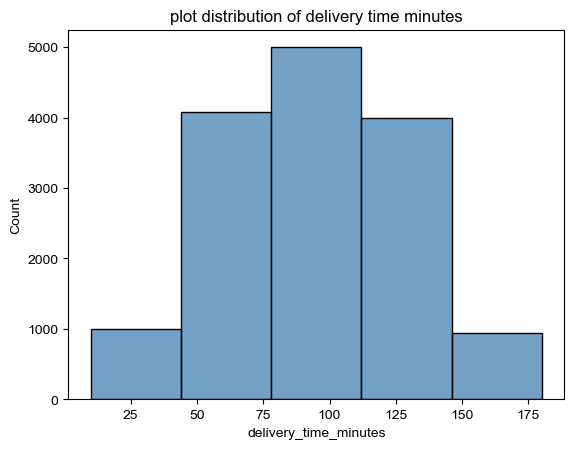

In [31]:
# Plot distribution of delivery_time_minutes using histplot

sns.histplot(df,x="delivery_time_minutes",bins=5,color="steelblue")
sns.set_style("whitegrid")
plt.title("plot distribution of delivery time minutes")
plt.show()

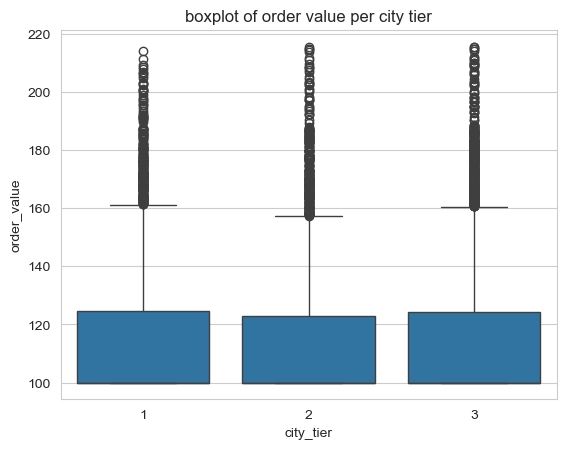

In [32]:
# Boxplot of order_value per city_tier

sns.boxplot(df,x="city_tier",y="order_value")
sns.set_style("whitegrid")
plt.title("boxplot of order value per city tier")
plt.show()

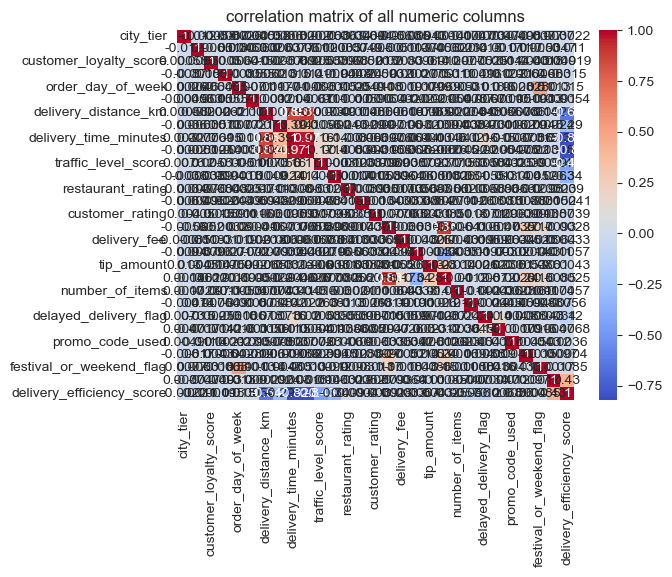

In [33]:
# Heatmap of correlation matrix of all numeric columns

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
sns.set_style("white")
plt.title("correlation matrix of all numeric columns")
plt.show()

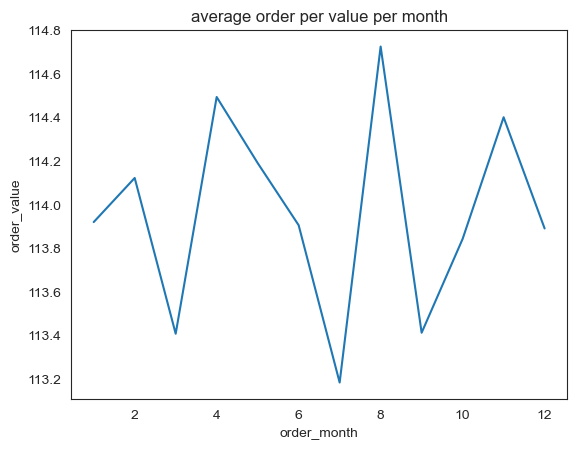

In [34]:
# Lineplot of average order value per month

sns.lineplot(data= df.groupby("order_month")["order_value"].mean().reset_index(),x="order_month",y="order_value")
plt.title("average order per value per month")
plt.show()

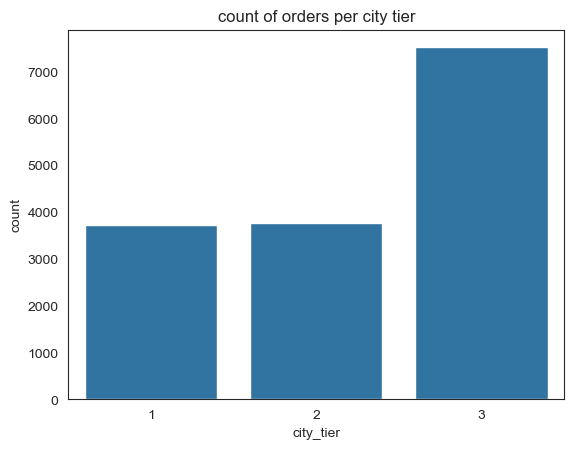

In [35]:
# Plot the count of orders per city tier using countplot.
sns.countplot(df,x="city_tier")
plt.title("count of orders per city tier")
plt.show()

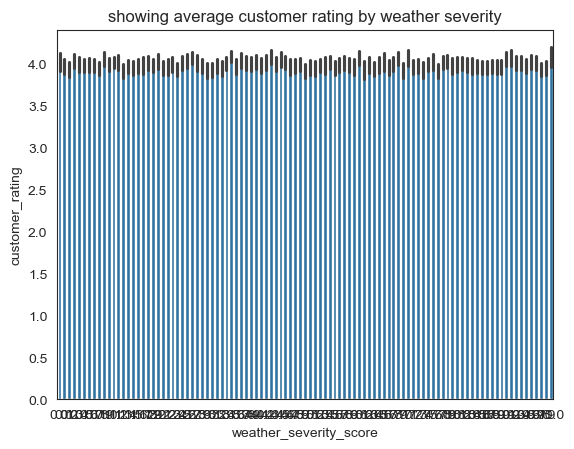

In [36]:
# Create a barplot showing average customer rating by weather severity.


sns.barplot(data = df,x="weather_severity_score",y="customer_rating")
plt.title("showing average customer rating by weather severity")
plt.show()

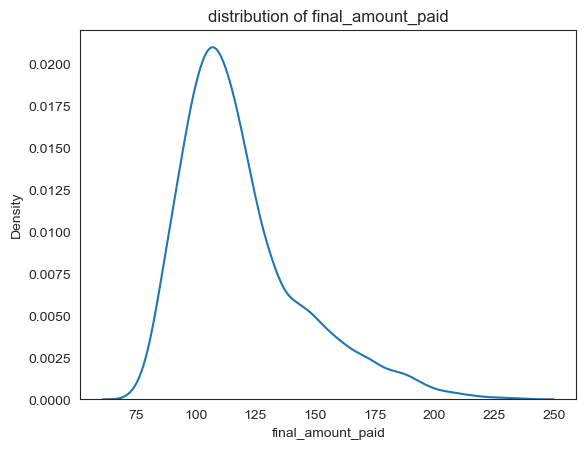

In [37]:
# Plot the distribution of final_amount_paid using kdeplot.

sns.kdeplot(data=df,x="final_amount_paid")
plt.title("distribution of final_amount_paid")
plt.show()

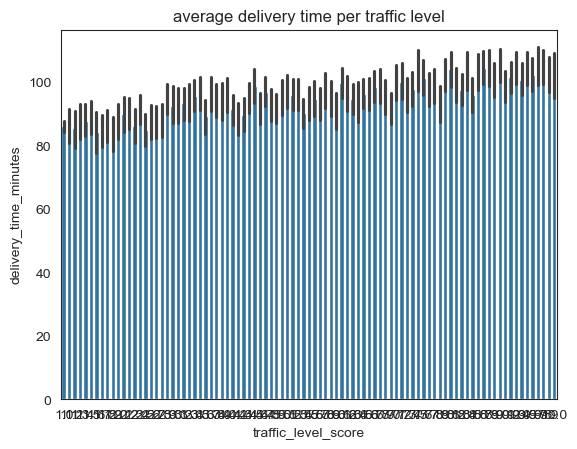

In [38]:
# Plot average delivery time per traffic level using barplot.

sns.barplot(data=df,x="traffic_level_score",y="delivery_time_minutes")
plt.title("average delivery time per traffic level")
plt.show()

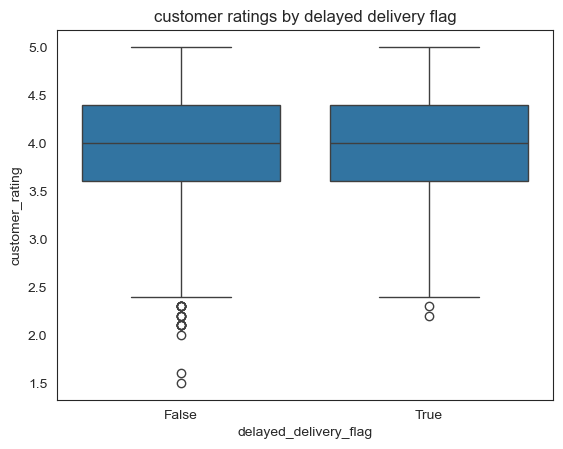

In [39]:
# Create a boxplot of customer ratings by delayed delivery flag.

sns.boxplot(data=df,x="delayed_delivery_flag",y="customer_rating")
plt.title("customer ratings by delayed delivery flag")
plt.show()

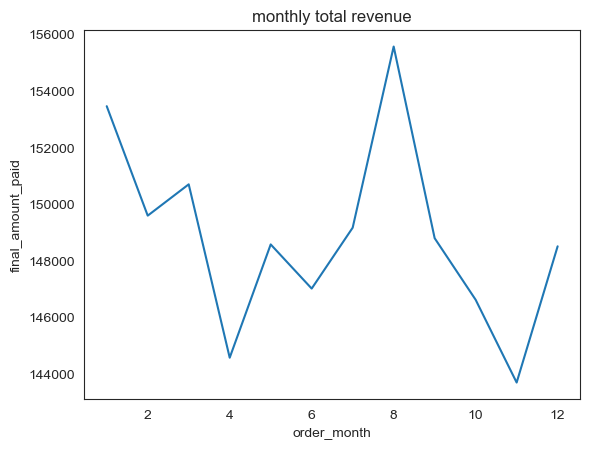

In [40]:
# Plot monthly total revenue using lineplot.do it again

sns.lineplot(data=df.groupby("order_month")["final_amount_paid"].sum().reset_index(),x="order_month",y="final_amount_paid")
plt.title("monthly total revenue")
plt.show()

<hr>

# Stats

In [41]:
from scipy import stats
import pandas as pd
import numpy as np

# T test- do pemium customers spend more ?

In [42]:
premium = df[df["premium_customer_flag"]==True]["final_amount_paid"]
non_premium=df[df["premium_customer_flag"]==False]["final_amount_paid"]

t_stat,p_value=stats.ttest_ind(premium,non_premium)
print("T-test p-value  : ",p_value)

if p_value<0.05:
    print("premium customers spend significantly more ")
else:
    print("no significant difference")    

T-test p-value  :  2.2736237804226578e-188
premium customers spend significantly more 


In [43]:
# confidence interval on delivery time

delivery=df["delivery_time_minutes"]
ci=stats.t.interval(0.95,df=len(delivery)-1,loc=delivery.mean(),scale=stats.sem(delivery))
print("\n95% CI for delivery time: ",ci)


95% CI for delivery time:  (np.float64(93.60156707069123), np.float64(94.67696626264211))


# 3.chi square city tier vs cancellation 

In [44]:
contingency = pd.crosstab(df["city_tier"],df["cancellation_flag"])

chi_stat,p_val,dof,expected=stats.chi2_contingency(contingency)
print("chi-square,p-val: ",p_val)

if p_val < 0.05:
    print("City tier affects cancellation rate")
else:
    print("No significant effect")

chi-square,p-val:  0.8368027493986303
No significant effect


# 4. Skewness and Kurtosis

In [45]:

print("\nfinal_amount_paid skewness:", df["final_amount_paid"].skew())
print("final_amount_paid kurtosis:", df["final_amount_paid"].kurt())
print("delivery_time_minutes skewness:", df["delivery_time_minutes"].skew())
print("delivery_time_minutes kurtosis:", df["delivery_time_minutes"].kurt())


final_amount_paid skewness: 1.1724311973507997
final_amount_paid kurtosis: 1.337546151085443
delivery_time_minutes skewness: -0.002747062438750642
delivery_time_minutes kurtosis: -0.7238290004957837


T-test → p-value basically zero → premium customers spend significantly more 

CI → 95% sure average delivery time is between 93.6 and 94.7 minutes 

Chi-square → p-value 0.84 → city tier does NOT affect cancellation rate 


# Skewness:

final_amount_paid → 1.17 → right skewed → few high value orders pulling it

delivery_time_minutes → -0.003 → almost perfectly normal 

# Kurtosis:

final_amount_paid → 1.34 → slightly heavy tailed

delivery_time_minutes → -0.72 → flat distribution, no extreme outliers 

# Feature Engineering 

In [46]:
df["delivery_gap"]=(df["delivery_time_minutes"]-df["estimated_delivery_time"])
df["traffic_weather_score"]=(df["traffic_level_score"]*df["weather_severity_score"])
df["avg_item_value"]=(df["order_value"]/df["number_of_items"])
df["discount_percentage"]=(df["discount_amount"]/df["order_value"]+1*100)
df["fee_per_km"]=(df["delivery_fee"]/df["delivery_distance_km"])

In [47]:
df.select_dtypes(include="object").columns

Index(['order_id'], dtype='object')

lets remove order id its is not useful for this model

In [48]:
df=df.drop("order_id",axis=1)

# Features and target 

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   city_tier                          15000 non-null  int64   
 1   customer_age                       15000 non-null  int64   
 2   customer_loyalty_score             15000 non-null  float64 
 3   order_hour                         15000 non-null  int64   
 4   order_day_of_week                  15000 non-null  int64   
 5   order_month                        15000 non-null  int64   
 6   delivery_distance_km               15000 non-null  float64 
 7   preparation_time_minutes           15000 non-null  int64   
 8   delivery_time_minutes              15000 non-null  int64   
 9   estimated_delivery_time            15000 non-null  int64   
 10  traffic_level_score                15000 non-null  float64 
 11  weather_severity_score             15000 

since there are no categorical columns no label and one hot encoding needed 

In [50]:
df.nunique().sort_values()

premium_customer_flag                    2
promo_code_used                          2
refund_flag                              2
delayed_delivery_flag                    2
cancellation_flag                        2
festival_or_weekend_flag                 2
city_tier                                3
age_group                                4
order_day_of_week                        6
order_month                             12
number_of_items                         12
delivery_partner_experience_years       15
order_hour                              24
delivery_partner_rating                 24
restaurant_rating                       28
customer_rating                         33
preparation_time_minutes                56
delivery_gap                            58
customer_age                            58
traffic_level_score                     91
weather_severity_score                 101
estimated_delivery_time                162
delivery_time_minutes                  171
delivery_ef

city_tier = 3 → Low cardinality categorical feature 

order_month = 12 → 12 months 

order_hour = 24 → Hours 0–23 

age_group since we already have customer age lets drop age group 

In [51]:
df=df.drop("age_group",axis=1)

In [52]:
# features and target
x=df.drop("delayed_delivery_flag",axis=1)
y=df["delayed_delivery_flag"]

if we drop any column in x variable it only removes in that variable not in original df if we want drop colum  we have to do it seperately 

In [53]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [54]:
x.isnull().sum().sort_values(ascending=False)

customer_rating                      150
delivery_partner_rating              150
tip_amount                           150
city_tier                              0
premium_customer_flag                  0
number_of_items                        0
cancellation_flag                      0
refund_flag                            0
promo_code_used                        0
festival_or_weekend_flag               0
delivery_partner_experience_years      0
delivery_efficiency_score              0
delivery_gap                           0
traffic_weather_score                  0
avg_item_value                         0
discount_percentage                    0
final_amount_paid                      0
delivery_fee                           0
discount_amount                        0
customer_age                           0
order_value                            0
restaurant_rating                      0
weather_severity_score                 0
traffic_level_score                    0
estimated_delive

only 150 missing values in 15,000 rows we can fill with median

# filling missing values with median 

In [55]:
x["customer_rating"]=x["customer_rating"].fillna(x["customer_rating"].median())

x["delivery_partner_rating"]=x["delivery_partner_rating"].fillna(x["delivery_partner_rating"].median())

x["tip_amount"]=x["tip_amount"].fillna(x["tip_amount"].median())

In [56]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
print(x.select_dtypes(include="category").columns)

Index([], dtype='object')


In [58]:
# create model
lg_model=LogisticRegression()
Rf_model=RandomForestClassifier()
xgb_model=XGBClassifier(n_estimators=100,random_state=42)
adb_model=AdaBoostClassifier(n_estimators=100,random_state=42)

In [59]:
# train the model

lg_model.fit(x_train,y_train)
Rf_model.fit(x_train,y_train)
xgb_model.fit(x_train,y_train)
adb_model.fit(x_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [60]:
# predict the model
lg_y_pred=lg_model.predict(x_test)
Rf_y_pred=Rf_model.predict(x_test)
xgb_y_pred=xgb_model.predict(x_test)
adb_y_pred=adb_model.predict(x_test)

In [61]:
# evaluation metrics

print("accuracy score : ",accuracy_score(y_test,lg_y_pred))
print("accuracy score : ",accuracy_score(y_test,Rf_y_pred))
print("accuracy_score: ",accuracy_score(y_test,xgb_y_pred))
print("accuracy_score: ",accuracy_score(y_test,adb_y_pred))

print("confusion_matrix: ",confusion_matrix(y_test,Rf_y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,lg_y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,xgb_y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,adb_y_pred))


print("classification_report: ",classification_report(y_test,Rf_y_pred))
print("classification_report: ",classification_report(y_test,lg_y_pred))
print("classification_report: ",classification_report(y_test,xgb_y_pred))
print("classification_report: ",classification_report(y_test,adb_y_pred))

accuracy score :  1.0
accuracy score :  1.0
accuracy_score:  1.0
accuracy_score:  1.0
confusion_matrix:  [[2714    0]
 [   0  286]]
confusion_matrix:  [[2714    0]
 [   0  286]]
confusion_matrix:  [[2714    0]
 [   0  286]]
confusion_matrix:  [[2714    0]
 [   0  286]]
classification_report:                precision    recall  f1-score   support

       False       1.00      1.00      1.00      2714
        True       1.00      1.00      1.00       286

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

classification_report:                precision    recall  f1-score   support

       False       1.00      1.00      1.00      2714
        True       1.00      1.00      1.00       286

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

classification_report:      

all 4  models got 100% accuracy means data leakage; we need to check the target variable related varaibles that exist in x variable like 
delivery time minutes, delivery_gap, delivery efficiency score if they exist, and lets  drop them from x variable not from original dataframe

In [62]:
# to check whether specific  columns are present in x variable 
print("delivery_time_minutes" in x.columns,"delivery_gap"in x.columns,"delivery_efficiency_score" in x.columns)

True True True


all three columns are there in x variable 

The reason we drop delivery_time_minutes and delivery_gap is that they already contain information that directly determines whether a delivery was delayed.
Your target variable, delayed_delivery_flag, is based on comparing the actual delivery time with the estimated delivery time.
If the model can see delivery_time_minutes or delivery_gap, 
it can figure out the answer almost immediately instead of learning patterns from the other features. 
This is called data leakage because the model is using information that would not be available when making a real prediction.
On the other hand, features like traffic_level_score, weather_severity_score, and delivery_distance_km do not directly tell whether a delivery was delayed—they only provide clues that help the model make a prediction. 
That's why those features are kept, while the leakage columns are removed.

In [63]:
x=x.drop(["delivery_time_minutes","delivery_gap","delivery_efficiency_score"],axis=1)

In [64]:
# lets check again whether specific  columns are present in x variable 
print("delivery_time_minutes" in x.columns,"delivery_gap" in x.columns,"delivery_efficiency_score" in x.columns)

False False False


these columns dropped from x variable 

# now repeat the pipeline to check the accuracy score of 2 models

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# create the model
lg_model=LogisticRegression()
rf_model=RandomForestClassifier()
xgb_model=XGBClassifier(n_estimators=100,random_state=42)
adb_model=AdaBoostClassifier(n_estimators=100,random_state=42)

# train the model
lg_model.fit(x_train,y_train)
rf_model.fit(x_train,y_train)
xgb_model.fit(x_train,y_train)
adb_model.fit(x_train,y_train)


# predict the model
lg_y_pred=lg_model.predict(x_test)
rf_y_pred=rf_model.predict(x_test)
xgb_y_pred=xgb_model.predict(x_test)
adb_y_pred=adb_model.predict(x_test)

# evalauation metrics

print("accuracy score for lg : ",accuracy_score(y_test,lg_y_pred))
print("accuracy score  for rf : ",accuracy_score(y_test,rf_y_pred))
print("accuracy score for adb : ",accuracy_score(y_test,adb_y_pred))
print("accuracy score  for xgb : ",accuracy_score(y_test,xgb_y_pred))

accuracy score for lg :  0.9046666666666666
accuracy score  for rf :  0.9046666666666666
accuracy score for adb :  0.9046666666666666
accuracy score  for xgb :  0.9043333333333333


lg ,rf , adb tied at 90.4 % accuracy score we will pick Random Forest  because this is more robust than rest of the algorithms 

# cross validation

In [66]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(rf_model,x,y,cv=5)
print("scores: ",scores.mean())

scores:  0.9049333333333335


90% means model is reliable 

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {"n_estimators": [100, 200],"max_depth": [10, 20, None]}

grid = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=params,cv=5,scoring="f1_macro",verbose=1)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'n_estimators': [100, 200]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [69]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'n_estimators': 100}
0.47520335468416885


In [70]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9046666666666666
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2714
        True       0.00      0.00      0.00       286

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000



# feature importance 

                   Feature  Importance
21             refund_flag    0.085577
17              tip_amount    0.053015
6     delivery_distance_km    0.052578
2   customer_loyalty_score    0.050197
18       final_amount_paid    0.049395
15            delivery_fee    0.048690
28     discount_percentage    0.047829
29              fee_per_km    0.047526
16         discount_amount    0.046346
26   traffic_weather_score    0.044928


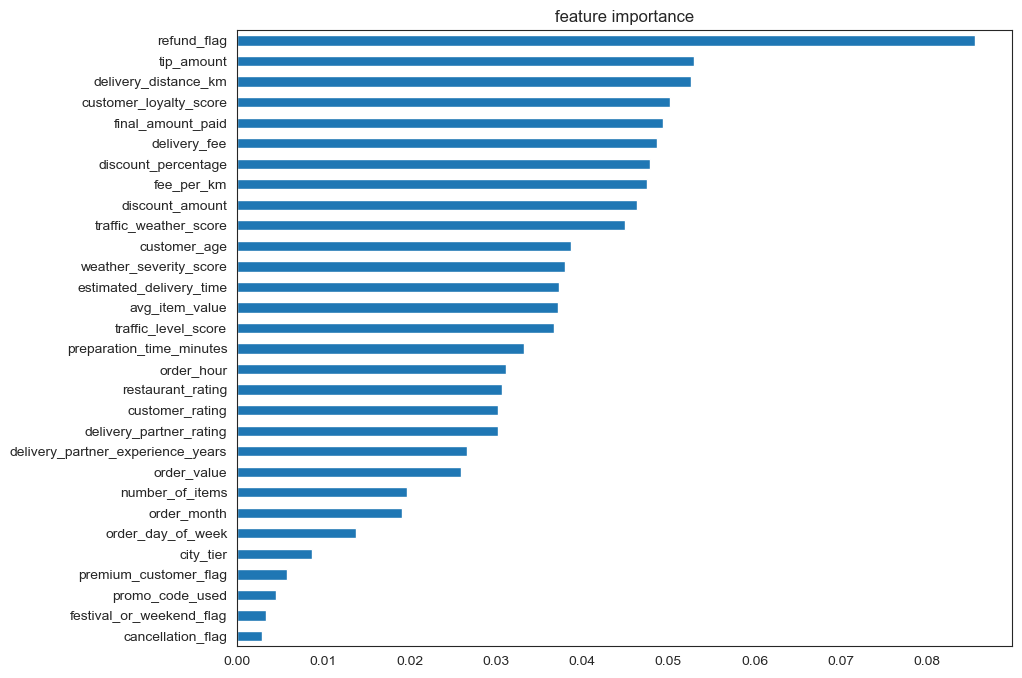

In [71]:
importance = pd.DataFrame({"Feature": x_train.columns,"Importance": best_rf.feature_importances_}).sort_values("Importance", ascending=False)

print(importance.head(10))

importance =pd.Series(best_rf.feature_importances_,index=x.columns)
importance.sort_values().plot(kind="barh",figsize=(10,8))
plt.title("feature importance")
plt.show()

based on this

refund flag feature  is higher and it indicates if  customer requested refund = delivery was likely delayed or wrong,

tip amount indicates happy customers tip more =low tip = bad experience = likely delayed

delivery distance indicates = longer distance =  higher chance of delay

Customer loyalty score indicates  loyal customers order more = model learned their patterns

Final amount paid indicates higher order value = more complex orders = more delay risk


these are the  top 5 strongest features in business insights for this model 


In [72]:
import joblib 
joblib.dump(best_rf,"delay_model.pk1")
joblib.dump(list(x_train.columns),"feature_columns.pk1")
print("model saved!")

model saved!



conclusion:

I built a delivery delay prediction system using Random Forest  After handling missing values removing data leakage and tuning hyperparameters with GridSearchCV the final model got approximately 90% accuracy and strong cross-validation performance. The most important features  influencing delivery delays were refund_flag , tip_amount , delivery_distance 